# ImageNet Validation Set Check

This notebook loads the ImageNet validation split through `torchvision.datasets.ImageNet` and visualizes a batch from a `DataLoader` with class labels.

In [1]:
import yaml, os, sys
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
from pathlib import Path
import json
import random
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageNet
from torchvision import transforms


The first time this runs, `ImageNet(..., split="val")` may extract `ILSVRC2012_img_val.tar` into `~/datasets/val/` and arrange images into class folders. Later runs reuse the extracted folder.

In [11]:
transform = transforms.Compose([
    transforms.Resize(384),
    transforms.CenterCrop(384),
    transforms.ToTensor(),
])

imagenet_val = ImageNet(root=paths["imagenet_path"], split="val", transform=transform)

In [12]:
assert len(imagenet_val) == 50_000, f"Expected 50,000 validation images, found {len(imagenet_val):,}"

random.seed(7)
sample_indices = random.sample(range(len(imagenet_val)), 16)
sample_dataset = Subset(imagenet_val, sample_indices)
loader = DataLoader(sample_dataset, batch_size=16, shuffle=False, num_workers=0)

images, targets = next(iter(loader))
images.shape, targets.shape

(torch.Size([16, 3, 384, 384]), torch.Size([16]))

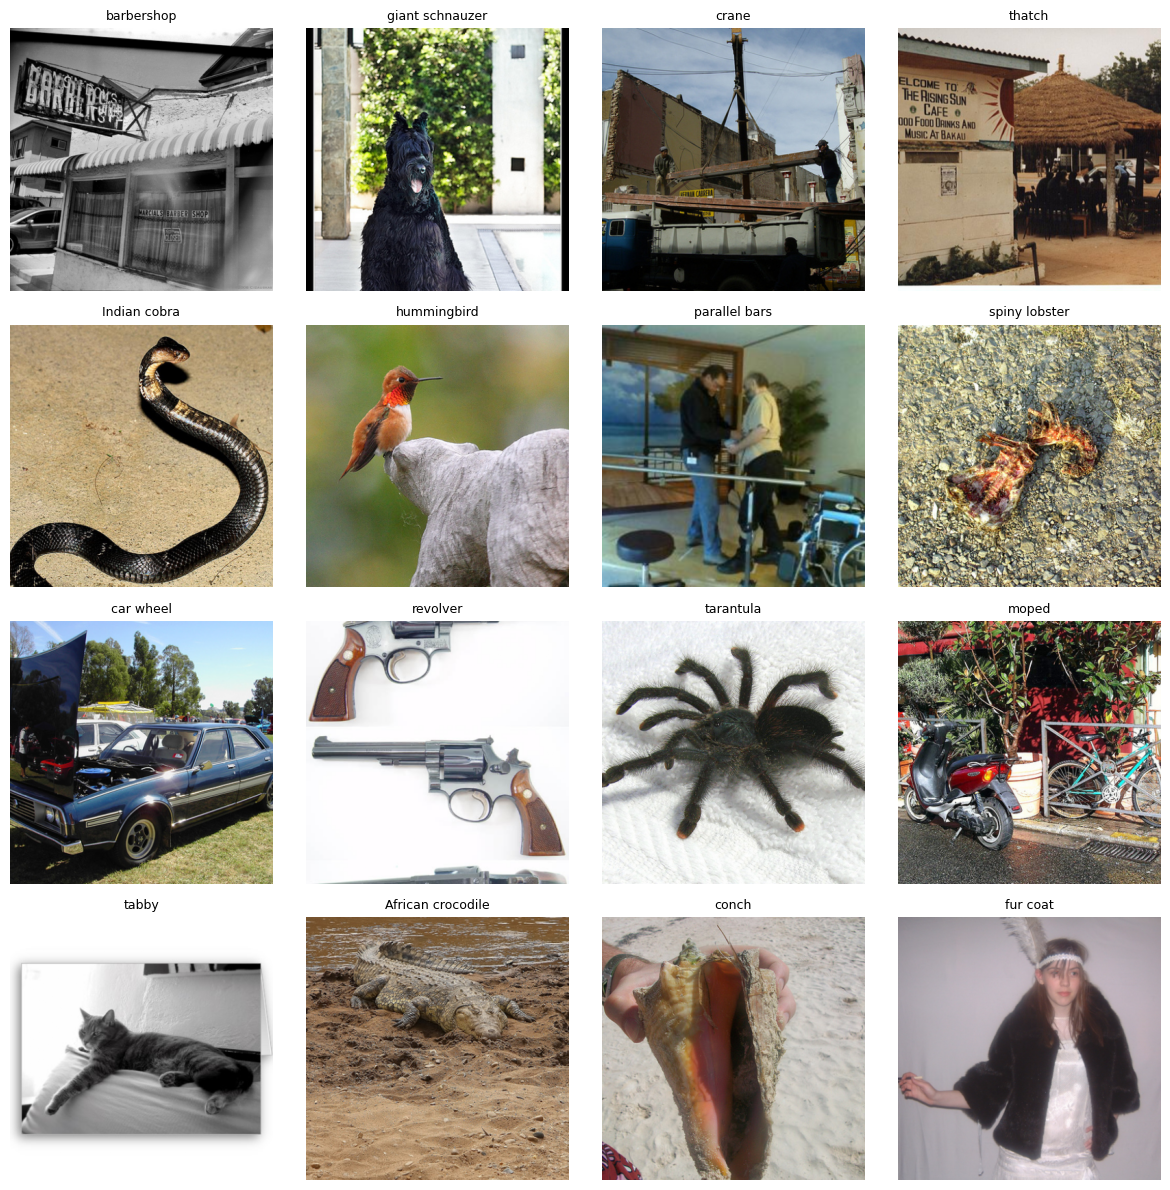

In [13]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for ax, image, target in zip(axes.flat, images, targets):
    class_names = imagenet_val.classes[int(target)]
    label = class_names[0] if isinstance(class_names, tuple) else class_names
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(label, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
random.seed(23)
sample_indices_2 = random.sample(range(len(imagenet_val)), 16)
sample_dataset_2 = Subset(imagenet_val, sample_indices_2)
loader_2 = DataLoader(sample_dataset_2, batch_size=16, shuffle=False, num_workers=0)

images_2, targets_2 = next(iter(loader_2))

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for ax, image, target in zip(axes.flat, images_2, targets_2):
    class_names = imagenet_val.classes[int(target)]
    label = class_names[0] if isinstance(class_names, tuple) else class_names
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(label, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()